<a href="https://colab.research.google.com/github/harshithareddy888/PortifolioProjects/blob/main/API_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': 'bb13cebf-51f8-4455-8f3b-ba884ed57bb4',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

{'status': {'timestamp': '2025-08-28T10:00:43.568Z', 'error_code': 0, 'error_message': None, 'elapsed': 24, 'credit_count': 1, 'notice': None, 'total_count': 9504}, 'data': [{'id': 1, 'name': 'Bitcoin', 'symbol': 'BTC', 'slug': 'bitcoin', 'num_market_pairs': 12296, 'date_added': '2010-07-13T00:00:00.000Z', 'tags': ['mineable', 'pow', 'sha-256', 'store-of-value', 'state-channel', 'coinbase-ventures-portfolio', 'three-arrows-capital-portfolio', 'polychain-capital-portfolio', 'binance-labs-portfolio', 'blockchain-capital-portfolio', 'boostvc-portfolio', 'cms-holdings-portfolio', 'dcg-portfolio', 'dragonfly-capital-portfolio', 'electric-capital-portfolio', 'fabric-ventures-portfolio', 'framework-ventures-portfolio', 'galaxy-digital-portfolio', 'huobi-capital-portfolio', 'alameda-research-portfolio', 'a16z-portfolio', '1confirmation-portfolio', 'winklevoss-capital-portfolio', 'usv-portfolio', 'placeholder-ventures-portfolio', 'pantera-capital-portfolio', 'multicoin-capital-portfolio', 'para

In [3]:
type(data)

dict

In [4]:
import pandas as pd

In [5]:
df=pd.json_normalize(data['data'])
df['timestamp']=pd.to_datetime('now') #creates a new column time stamp which consists of a the time it last updated/automated
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12296,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.991268e+07,1.991268e+07,...,57.4975,2.371598e+12,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
1,1027,Ethereum,ETH,ethereum,10476,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.207068e+08,1.207068e+08,...,14.1644,5.539871e+11,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
2,52,XRP,XRP,xrp,1682,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,5.948226e+10,9.998582e+10,...,4.5643,3.001161e+11,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
3,825,Tether USDt,USDT,tether,143076,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.673312e+11,1.707342e+11,...,4.2813,1.708517e+11,None,2025-08-28T09:59:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-08-28 10:00:44.702403
4,1839,BNB,BNB,bnb,2685,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",NaN,1.391880e+08,1.391880e+08,...,3.0827,1.205698e+11,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
5,5426,Solana,SOL,solana,976,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.406731e+08,6.084734e+08,...,2.9288,1.289159e+11,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
6,3408,USDC,USDC,usd-coin,30900,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,6.930347e+10,6.930347e+10,...,1.7727,6.933131e+10,None,2025-08-28T09:59:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-08-28 10:00:44.702403
7,74,Dogecoin,DOGE,dogecoin,1277,2013-12-15T00:00:00.000Z,"[mineable, pow, scrypt, medium-of-exchange, me...",NaN,1.507039e+11,1.507039e+11,...,0.8593,3.361008e+10,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
8,1958,TRON,TRX,tron,1216,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.466076e+10,9.466077e+10,...,0.8442,3.301586e+10,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403
9,2010,Cardano,ADA,cardano,1567,2017-10-01T00:00:00.000Z,"[dpos, pos, platform, research, smart-contract...",4.500000e+10,3.573184e+10,4.499468e+10,...,0.7918,3.899808e+10,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.702403


In [6]:
# automating function

def api_runner():
  global df
  url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
  parameters = {
    'start':'1',
    'limit':'15',
    'convert':'USD'
  }
  headers = {
    'Accepts': 'application/json',
    'X-CMC_PRO_API_KEY': 'bb13cebf-51f8-4455-8f3b-ba884ed57bb4',
  }

  session = Session()
  session.headers.update(headers)

  try:
    response = session.get(url, params=parameters)
    data = json.loads(response.text)
    # print(data)
  except (ConnectionError, Timeout, TooManyRedirects) as e:
    print(e)

  df2=pd.json_normalize(data['data'])
  df['timestamp']=pd.to_datetime('now') #creates a new column time stamp which consists of a the time it last updated/automated
  # df= pd.concat([df, df2], ignore_index=True) # Use pd.concat() instead of append()

  #saving the data frame into a csv file
  if not os.path.isfile('/content/crypto_data.csv'):
    df.to_csv('/content/crypto_data.csv', header='column_names')
  else:
    df.to_csv('/content/crypto_data.csv', mode='a', header=False)

In [7]:
import os
from time import time
from time import sleep

for i in range(332):
  api_runner()
  print('ran succesfully')
  sleep(60) #sleep for 1 min
exit()

ran succesfully


KeyboardInterrupt: 

In [8]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12296,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",2.100000e+07,1.991268e+07,1.991268e+07,...,57.4975,2.371598e+12,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
1,1027,Ethereum,ETH,ethereum,10476,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,1.207068e+08,1.207068e+08,...,14.1644,5.539871e+11,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
2,52,XRP,XRP,xrp,1682,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",1.000000e+11,5.948226e+10,9.998582e+10,...,4.5643,3.001161e+11,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
3,825,Tether USDt,USDT,tether,143076,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,1.673312e+11,1.707342e+11,...,4.2813,1.708517e+11,None,2025-08-28T09:59:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-08-28 10:00:44.989488
4,1839,BNB,BNB,bnb,2685,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",NaN,1.391880e+08,1.391880e+08,...,3.0827,1.205698e+11,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
5,5426,Solana,SOL,solana,976,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,5.406731e+08,6.084734e+08,...,2.9288,1.289159e+11,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
6,3408,USDC,USDC,usd-coin,30900,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,6.930347e+10,6.930347e+10,...,1.7727,6.933131e+10,None,2025-08-28T09:59:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-08-28 10:00:44.989488
7,74,Dogecoin,DOGE,dogecoin,1277,2013-12-15T00:00:00.000Z,"[mineable, pow, scrypt, medium-of-exchange, me...",NaN,1.507039e+11,1.507039e+11,...,0.8593,3.361008e+10,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
8,1958,TRON,TRX,tron,1216,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,9.466076e+10,9.466077e+10,...,0.8442,3.301586e+10,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
9,2010,Cardano,ADA,cardano,1567,2017-10-01T00:00:00.000Z,"[dpos, pos, platform, research, smart-contract...",4.500000e+10,3.573184e+10,4.499468e+10,...,0.7918,3.899808e+10,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488


In [9]:
import pandas as pd

# Read the data from the CSV file into a DataFrame
df_from_csv = pd.read_csv('/content/crypto_data.csv')

# Display the first few rows of the DataFrame
display(df_from_csv)

,Unnamed: 0,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,0,1,Bitcoin,BTC,bitcoin,12296,2010-07-13T00:00:00.000Z,"['mineable', 'pow', 'sha-256', 'store-of-value...",2.100000e+07,1.991268e+07,...,57.4975,2.371598e+12,NaN,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
1,1,1027,Ethereum,ETH,ethereum,10476,2015-08-07T00:00:00.000Z,"['pos', 'smart-contracts', 'ethereum-ecosystem...",NaN,1.207068e+08,...,14.1644,5.539871e+11,NaN,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
2,2,52,XRP,XRP,xrp,1682,2013-08-04T00:00:00.000Z,"['medium-of-exchange', 'enterprise-solutions',...",1.000000e+11,5.948226e+10,...,4.5643,3.001161e+11,NaN,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
3,3,825,Tether USDt,USDT,tether,143076,2015-02-25T00:00:00.000Z,"['stablecoin', 'asset-backed-stablecoin', 'usd...",NaN,1.673312e+11,...,4.2813,1.708517e+11,NaN,2025-08-28T09:59:00.000Z,1027.0,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-08-28 10:00:44.989488
4,4,1839,BNB,BNB,bnb,2685,2017-07-25T00:00:00.000Z,"['marketplace', 'centralized-exchange', 'payme...",NaN,1.391880e+08,...,3.0827,1.205698e+11,NaN,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
5,5,5426,Solana,SOL,solana,976,2020-04-10T00:00:00.000Z,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",NaN,5.406731e+08,...,2.9288,1.289159e+11,NaN,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
6,6,3408,USDC,USDC,usd-coin,30900,2018-10-08T00:00:00.000Z,"['medium-of-exchange', 'stablecoin', 'asset-ba...",NaN,6.930347e+10,...,1.7727,6.933131e+10,NaN,2025-08-28T09:59:00.000Z,1027.0,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-08-28 10:00:44.989488
7,7,74,Dogecoin,DOGE,dogecoin,1277,2013-12-15T00:00:00.000Z,"['mineable', 'pow', 'scrypt', 'medium-of-excha...",NaN,1.507039e+11,...,0.8593,3.361008e+10,NaN,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
8,8,1958,TRON,TRX,tron,1216,2017-09-13T00:00:00.000Z,"['media', 'payments', 'tron-ecosystem', 'layer...",NaN,9.466076e+10,...,0.8442,3.301586e+10,NaN,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
9,9,2010,Cardano,ADA,cardano,1567,2017-10-01T00:00:00.000Z,"['dpos', 'pos', 'platform', 'research', 'smart...",4.500000e+10,3.573184e+10,...,0.7918,3.899808e+10,NaN,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488


In [10]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [11]:
df

,id,name,symbol,slug,num_market_pairs,date_added,tags,max_supply,circulating_supply,total_supply,...,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.name,platform.symbol,platform.slug,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,12296,2010-07-13T00:00:00.000Z,"[mineable, pow, sha-256, store-of-value, state...",21000000.00000,19912675.00000,19912675.00000,...,57.49750,2371598063905.81006,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
1,1027,Ethereum,ETH,ethereum,10476,2015-08-07T00:00:00.000Z,"[pos, smart-contracts, ethereum-ecosystem, coi...",NaN,120706789.03886,120706789.03886,...,14.16440,553987063695.50000,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
2,52,XRP,XRP,xrp,1682,2013-08-04T00:00:00.000Z,"[medium-of-exchange, enterprise-solutions, xrp...",100000000000.00000,59482264023.00000,99985819185.00000,...,4.56430,300116059909.39001,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
3,825,Tether USDt,USDT,tether,143076,2015-02-25T00:00:00.000Z,"[stablecoin, asset-backed-stablecoin, usd-stab...",NaN,167331219172.95526,170734243944.68192,...,4.28130,170851718573.82001,None,2025-08-28T09:59:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xdac17f958d2ee523a2206206994597c13d831ec7,2025-08-28 10:00:44.989488
4,1839,BNB,BNB,bnb,2685,2017-07-25T00:00:00.000Z,"[marketplace, centralized-exchange, payments, ...",NaN,139187958.67000,139187958.67000,...,3.08270,120569797895.42000,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
5,5426,Solana,SOL,solana,976,2020-04-10T00:00:00.000Z,"[pos, platform, solana-ecosystem, cms-holdings...",NaN,540673092.30777,608473401.53883,...,2.92880,128915877746.80000,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
6,3408,USDC,USDC,usd-coin,30900,2018-10-08T00:00:00.000Z,"[medium-of-exchange, stablecoin, asset-backed-...",NaN,69303469008.60716,69303469008.60716,...,1.77270,69331313675.64999,None,2025-08-28T09:59:00.000Z,1027.00000,Ethereum,ETH,ethereum,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2025-08-28 10:00:44.989488
7,74,Dogecoin,DOGE,dogecoin,1277,2013-12-15T00:00:00.000Z,"[mineable, pow, scrypt, medium-of-exchange, me...",NaN,150703946383.70526,150703946383.70526,...,0.85930,33610075397.09000,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
8,1958,TRON,TRX,tron,1216,2017-09-13T00:00:00.000Z,"[media, payments, tron-ecosystem, layer-1, dwf...",NaN,94660763398.47157,94660767236.07063,...,0.84420,33015861961.21000,None,2025-08-28T10:00:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488
9,2010,Cardano,ADA,cardano,1567,2017-10-01T00:00:00.000Z,"[dpos, pos, platform, research, smart-contract...",45000000000.00000,35731844808.46489,44994681861.70843,...,0.79180,38998082976.44000,None,2025-08-28T09:59:00.000Z,NaN,NaN,NaN,NaN,NaN,2025-08-28 10:00:44.989488


In [13]:
df3=df.groupby('name',sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,-0.16560,1.90439,-0.38570,-4.92140,4.66110,6.89164
Ethereum,-0.33957,-0.00168,7.35809,18.47999,87.38566,75.62664
XRP,0.08889,-0.30858,3.69568,-5.01723,36.95952,36.78813
Tether USDt,0.02776,0.06912,0.08768,0.07611,0.05510,0.04688
BNB,-0.50822,0.98613,1.68680,4.10021,33.24153,29.43947
Solana,-0.91807,3.91305,14.60100,14.76240,40.10441,29.90220
USDC,-0.05918,0.04795,0.06565,0.05579,0.06243,0.06879
Dogecoin,-0.52165,1.28795,2.14664,-2.57198,35.41889,8.92386
TRON,-0.16139,-0.09464,-1.27138,3.01289,26.58156,28.39741


In [14]:
df4 = df3.stack()
df4

name                                 
Bitcoin  quote.USD.percent_change_1h     -0.16560
         quote.USD.percent_change_24h     1.90439
         quote.USD.percent_change_7d     -0.38570
         quote.USD.percent_change_30d    -4.92140
         quote.USD.percent_change_60d     4.66110
                                           ...   
Stellar  quote.USD.percent_change_24h    -1.17199
         quote.USD.percent_change_7d     -3.78711
         quote.USD.percent_change_30d   -11.18811
         quote.USD.percent_change_60d    59.22076
         quote.USD.percent_change_90d    39.76270
Length: 90, dtype: float64

In [16]:
type(df4)

pandas.core.series.Series

pandas.core.series.Series

In [17]:
df5=df4.to_frame(name='values')
df5

values
name                                          
Bitcoin quote.USD.percent_change_1h   -0.16560
        quote.USD.percent_change_24h   1.90439
        quote.USD.percent_change_7d   -0.38570
        quote.USD.percent_change_30d  -4.92140
        quote.USD.percent_change_60d   4.66110
...                                        ...
Stellar quote.USD.percent_change_24h  -1.17199
        quote.USD.percent_change_7d   -3.78711
        quote.USD.percent_change_30d -11.18811
        quote.USD.percent_change_60d  59.22076
        quote.USD.percent_change_90d  39.76270

[90 rows x 1 columns]

In [18]:
df5.count()

,0
values,90


In [22]:
index= pd.Index(range(90))
df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,-0.16560
1,Bitcoin,quote.USD.percent_change_24h,1.90439
2,Bitcoin,quote.USD.percent_change_7d,-0.38570
3,Bitcoin,quote.USD.percent_change_30d,-4.92140
4,Bitcoin,quote.USD.percent_change_60d,4.66110
...,...,...,...
85,Stellar,quote.USD.percent_change_24h,-1.17199
86,Stellar,quote.USD.percent_change_7d,-3.78711
87,Stellar,quote.USD.percent_change_30d,-11.18811
88,Stellar,quote.USD.percent_change_60d,59.22076


In [23]:
#cleaning the x axis column names
df6.rename(columns={'level_1':'percent_change'}, inplace=True)
df6

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,-0.16560
1,Bitcoin,quote.USD.percent_change_24h,1.90439
2,Bitcoin,quote.USD.percent_change_7d,-0.38570
3,Bitcoin,quote.USD.percent_change_30d,-4.92140
4,Bitcoin,quote.USD.percent_change_60d,4.66110
...,...,...,...
85,Stellar,quote.USD.percent_change_24h,-1.17199
86,Stellar,quote.USD.percent_change_7d,-3.78711
87,Stellar,quote.USD.percent_change_30d,-11.18811
88,Stellar,quote.USD.percent_change_60d,59.22076


In [27]:
df6['percent_change']=df6['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df6

,name,percent_change,values
0,Bitcoin,1h,-0.16560
1,Bitcoin,24h,1.90439
2,Bitcoin,7d,-0.38570
3,Bitcoin,30d,-4.92140
4,Bitcoin,60d,4.66110
...,...,...,...
85,Stellar,24h,-1.17199
86,Stellar,7d,-3.78711
87,Stellar,30d,-11.18811
88,Stellar,60d,59.22076


In [24]:
import seaborn as sns
import matplotlib.pyplot as plt


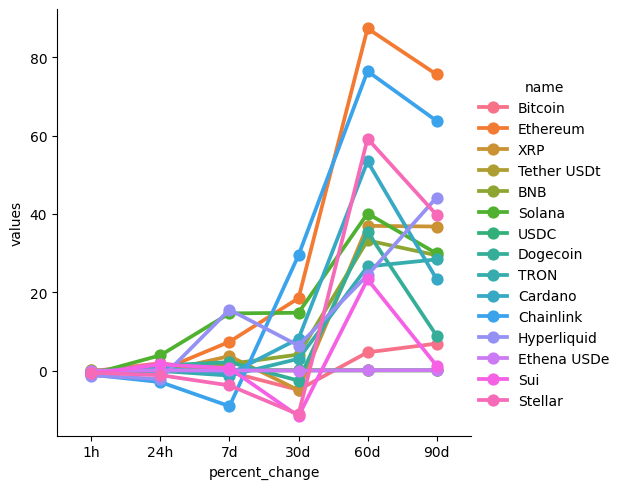

In [28]:
sns.catplot(x='percent_change', y='values', hue='name', data=df6, kind='point')

In [33]:
df7=df[['name','quote.USD.price','timestamp']]
# df7=df7.query("name=='Bitcoin'")
df7

,name,quote.USD.price,timestamp
0,Bitcoin,112933.24114,2025-08-28 10:00:44.989488
1,Ethereum,4589.52697,2025-08-28 10:00:44.989488
2,XRP,3.00116,2025-08-28 10:00:44.989488
3,Tether USDt,1.00069,2025-08-28 10:00:44.989488
4,BNB,866.23727,2025-08-28 10:00:44.989488
5,Solana,211.86773,2025-08-28 10:00:44.989488
6,USDC,1.00040,2025-08-28 10:00:44.989488
7,Dogecoin,0.22302,2025-08-28 10:00:44.989488
8,TRON,0.34878,2025-08-28 10:00:44.989488
9,Cardano,0.86662,2025-08-28 10:00:44.989488


<Axes: xlabel='timestamp', ylabel='quote.USD.price'>

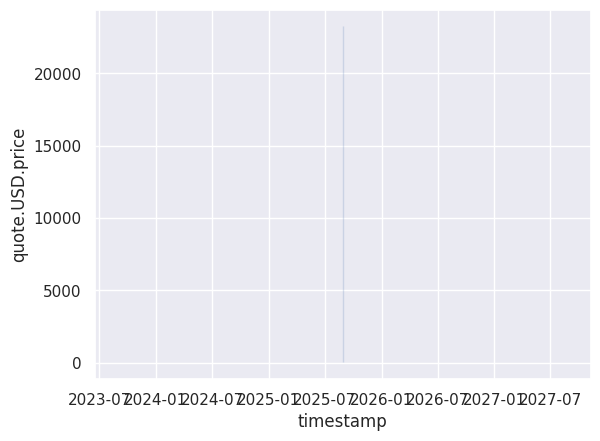

In [35]:
sns.set_theme(style='darkgrid')

sns.lineplot(x='timestamp', y='quote.USD.price', data=df7)